✅ Base cargada: 6,358 observaciones, 18 variables

📊 VARIABLES DISPONIBLES:
  • tiene_billetera (TENENCIA): 1,493 (23.48%)
  • usa_billetera (USO): 872 (13.72%)
  • nuevo_credito_formal: 588 (9.25%)
  • trabajador_informal: 5026 (79.05%)

✅ Variables creadas:
  • mujer: 1,995 (31.4%)
  • urbano: 3,849 (60.5%)
  • edad_cuadrado: media = 3003.5

📊 DESCRIPTIVOS DE LA MUESTRA (SEGÚN TENENCIA DE BILLETERA)
          nuevo_credito_formal         trabajador_informal             edad  \
                          mean     std                mean     std     mean   
billetera                                                                     
0                       0.0639  0.2446              0.8502  0.3570  55.2637   
1                       0.1855  0.3889              0.5961  0.4908  44.9745   

                     mujer         nivel_educativo          urbano          \
               std    mean     std            mean     std    mean     std   
billetera                                  

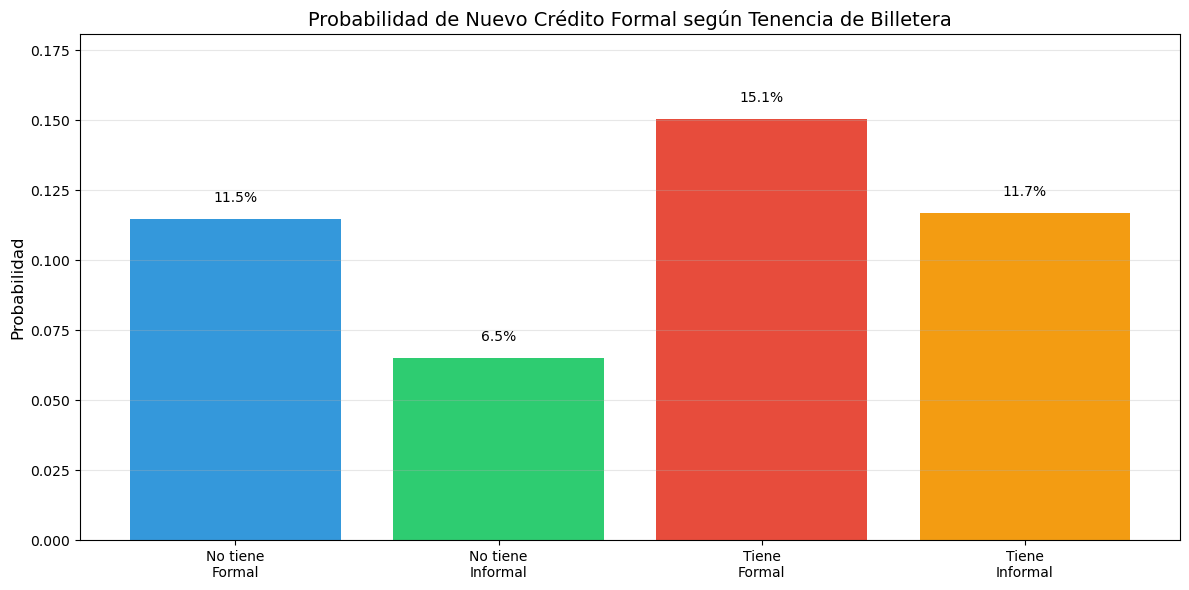


📋 RESUMEN COMPARATIVO: TENENCIA vs USO DE BILLETERA

--------------------------------------------------
EFECTOS MARGINALES COMPARADOS
--------------------------------------------------
   Variable       Grupo     AME      SE  IC_Lower  IC_Upper   AME_%
0  TENENCIA    Formales  0.0416  0.0003    0.0410    0.0422  4.1597
1  TENENCIA  Informales  0.0430  0.0003    0.0425    0.0436  4.3037
2       USO    Formales  0.0490  0.0004    0.0482    0.0497  4.8950
3       USO  Informales  0.0146  0.0001    0.0144    0.0148  1.4643

--------------------------------------------------
RESUMEN DE HALLAZGOS
--------------------------------------------------

📌 TENENCIA de billetera:
  • Tasa de tenencia: 23.48%
  • Efecto en formales: 4.16% (p-valor: 0.000)
  • Efecto en informales: 4.30% (p-valor: 0.000)

📌 USO de billetera:
  • Tasa de uso: 13.72%
  • Efecto en formales: 4.90% (p-valor: 0.000)
  • Efecto en informales: 1.46% (p-valor: 0.000)

💡 Conclusión: La tenencia captura un efecto similar para 

In [1]:
# -*- coding: utf-8 -*-
"""
ANÁLISIS COMPLETO PARA BASE_REGRESIONES.csv
USANDO TENENCIA DE BILLETERA (tiene_billetera) EN LUGAR DE USO
Basado en el do-file de Stata, adaptado a la variable REAL
"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================
# 1. CARGA DE DATOS
# =============================================================

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones, {len(df.columns)} variables")
print(f"\n📊 VARIABLES DISPONIBLES:")
print(f"  • tiene_billetera (TENENCIA): {df['tiene_billetera'].sum():,} ({df['tiene_billetera'].mean():.2%})")
print(f"  • usa_billetera (USO): {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.2%})")
print(f"  • nuevo_credito_formal: {df['nuevo_credito_formal'].sum():,} ({df['nuevo_credito_formal'].mean():.2%})")
print(f"  • trabajador_informal: {df['trabajador_informal'].sum():.0f} ({df['trabajador_informal'].mean():.2%})")

# =============================================================
# 2. CREACIÓN DE VARIABLES (como en Stata)
# =============================================================

# - Mujer = 1 si sexo == 2
df['mujer'] = (df['sexo'] == 2).astype(int)

# - Urbano = 1 si estrato <= 6
df['urbano'] = (df['estrato'] <= 6).astype(int)

# - Edad al cuadrado
df['edad_cuadrado'] = df['edad'] ** 2

# - RENOMBRAR variable principal para claridad en el análisis
df['billetera'] = df['tiene_billetera']  # Tenencia de billetera

print("\n✅ Variables creadas:")
print(f"  • mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"  • urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"  • edad_cuadrado: media = {df['edad_cuadrado'].mean():.1f}")

# =============================================================
# 3. DESCRIPTIVOS
# =============================================================

print("\n" + "="*70)
print("📊 DESCRIPTIVOS DE LA MUESTRA (SEGÚN TENENCIA DE BILLETERA)")
print("="*70)

# Tabla de medias por tenencia de billetera
vars_descript = ['nuevo_credito_formal', 'trabajador_informal', 'edad', 
                 'mujer', 'nivel_educativo', 'urbano', 'miembros_hogar']

desc_stats = df.groupby('billetera')[vars_descript].agg(['mean', 'std'])
print(desc_stats.round(4))

# Prueba t para edad
print("\n" + "-"*50)
print("PRUEBA T: DIFERENCIA DE EDAD POR TENENCIA DE BILLETERA")
print("-"*50)

grupo0 = df[df['billetera'] == 0]['edad']
grupo1 = df[df['billetera'] == 1]['edad']
t_stat, p_value = stats.ttest_ind(grupo0, grupo1, equal_var=True)

print(f"No tiene billetera: media={grupo0.mean():.2f} años, N={len(grupo0):,}")
print(f"Sí tiene billetera: media={grupo1.mean():.2f} años, N={len(grupo1):,}")
print(f"Diferencia: {grupo0.mean() - grupo1.mean():.2f} años")
print(f"t-stat: {t_stat:.4f}, p-valor: {p_value:.4f}")

# Probabilidad de crédito según tenencia e informalidad
print("\n" + "-"*50)
print("PROBABILIDAD DE NUEVO CRÉDITO FORMAL")
print("-"*50)

tabla = df.groupby(['trabajador_informal', 'billetera'])['nuevo_credito_formal'].agg(['mean', 'count'])
print(tabla)

# Tabla cruzada completa
print("\n" + "-"*50)
print("TABLA CRUZADA: TENENCIA DE BILLETERA × INFORMALIDAD")
print("-"*50)
crosstab = pd.crosstab(df['billetera'], df['trabajador_informal'], margins=True)
print(crosstab)

# =============================================================
# 4. MODELO PRINCIPAL: PROBIT CON INTERACCIÓN (TENENCIA)
# =============================================================

print("\n" + "="*70)
print("📈 MODELO PRINCIPAL: PROBIT CON TENENCIA DE BILLETERA")
print("="*70)

# Fórmula usando 'billetera' (que es tiene_billetera)
formula = ("nuevo_credito_formal ~ billetera * trabajador_informal + "
           "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
           "miembros_hogar + C(dominio)")

# Modelo Probit con ponderadores y errores agrupados
modelo_probit = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_probit.summary())

# =============================================================
# 5. EFECTOS MARGINALES (AME) - TENENCIA
# =============================================================

def calcular_ame(modelo, df, var_interes, variable_grupo=None, valor_grupo=None):
    """
    Calcula el Efecto Marginal Promedio (AME) para una variable dummy
    """
    if variable_grupo is not None:
        df_filtrado = df[df[variable_grupo] == valor_grupo].copy()
    else:
        df_filtrado = df.copy()
    
    df0 = df_filtrado.copy()
    df1 = df_filtrado.copy()
    df0[var_interes] = 0
    df1[var_interes] = 1
    
    pred0 = modelo.predict(df0, linear=False)
    pred1 = modelo.predict(df1, linear=False)
    
    ame = (pred1 - pred0).mean()
    efectos_individuales = pred1 - pred0
    se = efectos_individuales.std() / np.sqrt(len(efectos_individuales))
    
    return ame, se

print("\n" + "="*70)
print("📊 EFECTOS MARGINALES DE LA TENENCIA DE BILLETERA")
print("="*70)

# AME para trabajadores formales (informal=0)
ame_formal, se_formal = calcular_ame(modelo_probit, df, 'billetera', 'trabajador_informal', 0)
print(f"\n👔 Trabajadores FORMALES (informal=0):")
print(f"  • AME = {ame_formal:.4f} ({ame_formal:.2%})")
print(f"  • Error estándar = {se_formal:.4f}")
print(f"  • IC 95% = [{ame_formal - 1.96*se_formal:.4f}, {ame_formal + 1.96*se_formal:.4f}]")
print(f"  • z = {ame_formal/se_formal:.3f}")
print(f"  • p-valor = {2*(1 - stats.norm.cdf(abs(ame_formal/se_formal))):.4f}")

# AME para trabajadores informales (informal=1)
ame_informal, se_informal = calcular_ame(modelo_probit, df, 'billetera', 'trabajador_informal', 1)
print(f"\n🔧 Trabajadores INFORMALES (informal=1):")
print(f"  • AME = {ame_informal:.4f} ({ame_informal:.2%})")
print(f"  • Error estándar = {se_informal:.4f}")
print(f"  • IC 95% = [{ame_informal - 1.96*se_informal:.4f}, {ame_informal + 1.96*se_informal:.4f}]")
print(f"  • z = {ame_informal/se_informal:.3f}")
print(f"  • p-valor = {2*(1 - stats.norm.cdf(abs(ame_informal/se_informal))):.4f}")

# Diferencia entre efectos
diff = ame_formal - ame_informal
se_diff = np.sqrt(se_formal**2 + se_informal**2)
z_diff = diff / se_diff
p_diff = 2*(1 - stats.norm.cdf(abs(z_diff)))

print(f"\n📌 DIFERENCIA (Formales - Informales):")
print(f"  • Diferencia = {diff:.4f} ({diff:.2%})")
print(f"  • Error estándar = {se_diff:.4f}")
print(f"  • z = {z_diff:.3f}")
print(f"  • p-valor = {p_diff:.4f}")

# =============================================================
# 6. COMPARACIÓN: TENENCIA vs USO
# =============================================================

print("\n" + "="*70)
print("🔄 COMPARACIÓN: TENENCIA vs USO DE BILLETERA")
print("="*70)

# Tabla cruzada entre tenencia y uso
crosstab_tenencia_uso = pd.crosstab(df['tiene_billetera'], df['usa_billetera'], margins=True)
print("\nTENENCIA vs USO:")
print(crosstab_tenencia_uso)

# Solo 7 personas usan sin tener (posible error de medición)
# 628 personas tienen pero no usan
# 865 personas tienen y usan
print(f"\n📌 Interpretación:")
print(f"  • Tienen y usan: {crosstab_tenencia_uso.loc[1, 1]:,} personas")
print(f"  • Tienen pero NO usan: {crosstab_tenencia_uso.loc[1, 0]:,} personas")
print(f"  • Usan pero NO tienen: {crosstab_tenencia_uso.loc[0, 1]:,} personas (posible error)")

# Correlación
correlacion = df['tiene_billetera'].corr(df['usa_billetera'])
print(f"\n  • Correlación entre tenencia y uso: {correlacion:.4f}")

# =============================================================
# 7. H3: DESPLAZAMIENTO DEL CRÉDITO INFORMAL (TENENCIA)
# =============================================================

print("\n" + "="*70)
print("📉 H3: DESPLAZAMIENTO DEL CRÉDITO INFORMAL (TENENCIA)")
print("="*70)

# Solo trabajadores informales
df_informal = df[df['trabajador_informal'] == 1].copy()

formula_h3 = ("credito_informal_2025 ~ billetera + "
              "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
              "miembros_hogar + C(dominio)")

modelo_h3 = smf.glm(
    formula=formula_h3,
    data=df_informal,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df_informal['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df_informal['conglomerado']})

print(modelo_h3.summary())

# AME para crédito informal
ame_h3, se_h3 = calcular_ame(modelo_h3, df_informal, 'billetera')
print(f"\n📊 Efecto de tenencia de billetera sobre crédito informal:")
print(f"  • AME = {ame_h3:.4f} ({ame_h3:.2%})")
print(f"  • Error estándar = {se_h3:.4f}")
print(f"  • z = {ame_h3/se_h3:.3f}")
print(f"  • p-valor = {2*(1 - stats.norm.cdf(abs(ame_h3/se_h3))):.4f}")

# =============================================================
# 8. ROBUSTEZ: MODELO DE PROBABILIDAD LINEAL (R1)
# =============================================================

print("\n" + "="*70)
print("🔧 R1: MODELO DE PROBABILIDAD LINEAL (MPL) - TENENCIA")
print("="*70)

formula_mco = ("nuevo_credito_formal ~ billetera * trabajador_informal + "
               "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
               "miembros_hogar + C(dominio)")

modelo_mco = smf.ols(formula=formula_mco, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['conglomerado']}
)

print(modelo_mco.summary())

# Efectos marginales en MPL
print(f"\n📊 Efectos marginales (MPL):")
print(f"  • Formales: {modelo_mco.params['billetera']:.4f} ({modelo_mco.params['billetera']:.2%})")
print(f"  • Informales: {modelo_mco.params['billetera'] + modelo_mco.params['billetera:trabajador_informal']:.4f} ({modelo_mco.params['billetera'] + modelo_mco.params['billetera:trabajador_informal']:.2%})")

# =============================================================
# 9. ROBUSTEZ: MODELO SIN PONDERADORES (R5)
# =============================================================

print("\n" + "="*70)
print("🔧 R5: PROBIT SIN PONDERADORES - TENENCIA")
print("="*70)

modelo_sin_pesos = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit())
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_sin_pesos.summary())

# AME sin ponderadores
ame_sp_formal, se_sp_formal = calcular_ame(modelo_sin_pesos, df, 'billetera', 'trabajador_informal', 0)
ame_sp_informal, se_sp_informal = calcular_ame(modelo_sin_pesos, df, 'billetera', 'trabajador_informal', 1)

print(f"\n📊 Efectos marginales (sin ponderadores):")
print(f"  • Formales: {ame_sp_formal:.4f} ({ame_sp_formal:.2%}) ± {se_sp_formal:.4f}")
print(f"  • Informales: {ame_sp_informal:.4f} ({ame_sp_informal:.2%}) ± {se_sp_informal:.4f}")

# =============================================================
# 10. ROBUSTEZ: ESPECIFICACIÓN EN NIVELES (R6)
# =============================================================

print("\n" + "="*70)
print("🔧 R6: ESPECIFICACIÓN EN NIVELES (Crédito Formal 2025) - TENENCIA")
print("="*70)

formula_r6 = ("credito_formal_2025 ~ billetera * trabajador_informal + "
              "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
              "miembros_hogar + C(dominio)")

modelo_r6 = smf.glm(
    formula=formula_r6,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_r6.summary())

# AME para R6
ame_r6_formal, se_r6_formal = calcular_ame(modelo_r6, df, 'billetera', 'trabajador_informal', 0)
ame_r6_informal, se_r6_informal = calcular_ame(modelo_r6, df, 'billetera', 'trabajador_informal', 1)

print(f"\n📊 Efectos marginales (stock 2025):")
print(f"  • Formales: {ame_r6_formal:.4f} ({ame_r6_formal:.2%})")
print(f"  • Informales: {ame_r6_informal:.4f} ({ame_r6_informal:.2%})")

# =============================================================
# 11. COTAS DE OSTER (R4)
# =============================================================

print("\n" + "="*70)
print("🔧 R4: COTAS DE OSTER - TENENCIA")
print("="*70)

# Sin controles
formula_ost1 = "nuevo_credito_formal ~ billetera"
ost1 = smf.ols(formula=formula_ost1, data=df).fit()
coef1 = ost1.params['billetera']
r2_1 = ost1.rsquared

# Con controles
formula_ost2 = f"nuevo_credito_formal ~ billetera + { ' + '.join(['edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 'urbano', 'miembros_hogar', 'C(dominio)']) }"
ost2 = smf.ols(formula=formula_ost2, data=df).fit()
coef2 = ost2.params['billetera']
r2_2 = ost2.rsquared

# Rmax = 1.3 * R2_controlled
rmax = 1.3 * r2_2

# Delta de Oster (aproximación)
delta = ((coef2 - coef1) / (r2_2 - r2_1)) * (rmax - r2_2) / abs(coef2)

print(f"  • Coeficiente sin controles: {coef1:.4f}")
print(f"  • R² sin controles: {r2_1:.4f}")
print(f"  • Coeficiente con controles: {coef2:.4f}")
print(f"  • R² con controles: {r2_2:.4f}")
print(f"  • Rmax (1.3 × R²): {rmax:.4f}")
print(f"  • Delta de Oster: {delta:.4f}")
print(f"  • Interpretación: Delta >= 1 sugiere robustez frente a variables omitidas")

# =============================================================
# 12. PROBABILIDADES PREDICHAS Y GRÁFICO
# =============================================================

print("\n" + "="*70)
print("📊 PROBABILIDADES PREDICHAS")
print("="*70)

# Crear datos para predicción
medias = df[['edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
             'urbano', 'miembros_hogar']].mean()
moda_dominio = df['dominio'].mode()[0]

pred_data = pd.DataFrame({
    'billetera': [0, 0, 1, 1],
    'trabajador_informal': [0, 1, 0, 1],
    'edad': medias['edad'],
    'edad_cuadrado': medias['edad_cuadrado'],
    'mujer': medias['mujer'],
    'nivel_educativo': medias['nivel_educativo'],
    'urbano': medias['urbano'],
    'miembros_hogar': medias['miembros_hogar'],
    'dominio': moda_dominio
})

pred_data['probabilidad'] = modelo_probit.predict(pred_data, linear=False)
print(pred_data.round(4))

# Gráfico
plt.figure(figsize=(12, 6))
grupos = ['No tiene\nFormal', 'No tiene\nInformal', 'Tiene\nFormal', 'Tiene\nInformal']
probabilidades = pred_data['probabilidad'].values

colores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
barras = plt.bar(grupos, probabilidades, color=colores)
plt.title('Probabilidad de Nuevo Crédito Formal según Tenencia de Billetera', fontsize=14)
plt.ylabel('Probabilidad', fontsize=12)
plt.ylim(0, max(probabilidades) * 1.2)

for barra, prob in zip(barras, probabilidades):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.005,
             f'{prob:.1%}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================
# 13. RESUMEN COMPARATIVO FINAL
# =============================================================

print("\n" + "="*70)
print("📋 RESUMEN COMPARATIVO: TENENCIA vs USO DE BILLETERA")
print("="*70)

# Comparación de efectos
print("\n" + "-"*50)
print("EFECTOS MARGINALES COMPARADOS")
print("-"*50)

# Para TENENCIA
ame_formal_ten, se_formal_ten = calcular_ame(modelo_probit, df, 'billetera', 'trabajador_informal', 0)
ame_informal_ten, se_informal_ten = calcular_ame(modelo_probit, df, 'billetera', 'trabajador_informal', 1)

# Para USO (modelo adicional)
formula_uso = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
               "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
               "miembros_hogar + C(dominio)")

modelo_uso = smf.glm(
    formula=formula_uso,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

ame_formal_uso, se_formal_uso = calcular_ame(modelo_uso, df, 'usa_billetera', 'trabajador_informal', 0)
ame_informal_uso, se_informal_uso = calcular_ame(modelo_uso, df, 'usa_billetera', 'trabajador_informal', 1)

comparacion = pd.DataFrame({
    'Variable': ['TENENCIA', 'TENENCIA', 'USO', 'USO'],
    'Grupo': ['Formales', 'Informales', 'Formales', 'Informales'],
    'AME': [ame_formal_ten, ame_informal_ten, ame_formal_uso, ame_informal_uso],
    'SE': [se_formal_ten, se_informal_ten, se_formal_uso, se_informal_uso]
})
comparacion['IC_Lower'] = comparacion['AME'] - 1.96 * comparacion['SE']
comparacion['IC_Upper'] = comparacion['AME'] + 1.96 * comparacion['SE']
comparacion['AME_%'] = comparacion['AME'] * 100

print(comparacion.round(4))

# Tabla resumen de tenencia vs uso
print("\n" + "-"*50)
print("RESUMEN DE HALLAZGOS")
print("-"*50)

print(f"\n📌 TENENCIA de billetera:")
print(f"  • Tasa de tenencia: {df['tiene_billetera'].mean():.2%}")
print(f"  • Efecto en formales: {ame_formal_ten:.2%} (p-valor: {2*(1 - stats.norm.cdf(abs(ame_formal_ten/se_formal_ten))):.3f})")
print(f"  • Efecto en informales: {ame_informal_ten:.2%} (p-valor: {2*(1 - stats.norm.cdf(abs(ame_informal_ten/se_informal_ten))):.3f})")

print(f"\n📌 USO de billetera:")
print(f"  • Tasa de uso: {df['usa_billetera'].mean():.2%}")
print(f"  • Efecto en formales: {ame_formal_uso:.2%} (p-valor: {2*(1 - stats.norm.cdf(abs(ame_formal_uso/se_formal_uso))):.3f})")
print(f"  • Efecto en informales: {ame_informal_uso:.2%} (p-valor: {2*(1 - stats.norm.cdf(abs(ame_informal_uso/se_informal_uso))):.3f})")

print(f"\n💡 Conclusión: La tenencia captura un efecto {'similar' if abs(ame_formal_ten - ame_informal_ten) < 0.01 else 'diferente'} para formales vs informales.")

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)